# 2일차 과제 답안 - Boston 주택가격 데이터

**목표**
- 데이터 분석 문제 3개 이상 수행
- VIF 확인
- 상관관계 확인
- 상관관계 히트맵 작성
- 특성 데이터 정규화
- Train / Test 분할
- 특성 데이터를 이용한 `MEDV`(주택가격 중앙값) 예측
- 실제값과 예측값 Plot
- Train / Test 결정계수($R^2$) 확인

> `Unnamed: 0`는 데이터의 행 번호이므로 모델의 특성에서 제외하고, `medv`를 목표변수로 사용합니다.


## 1. 라이브러리 불러오기 및 데이터 확인

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 현재 작업 폴더에 Boston.csv가 있다고 가정
df = pd.read_csv("Boston.csv", index_col=0)

print("데이터 크기:", df.shape)
display(df.head())
display(df.describe())


데이터 크기: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 2. 문제 1 - 변수별 기본 통계 및 주택가격 분석

`MEDV`의 평균, 중앙값, 최소값, 최대값을 확인하고 주택가격의 분포를 살펴봅니다.

MEDV 평균: 22.532806324110677
MEDV 중앙값: 21.2
MEDV 최소값: 5.0
MEDV 최대값: 50.0


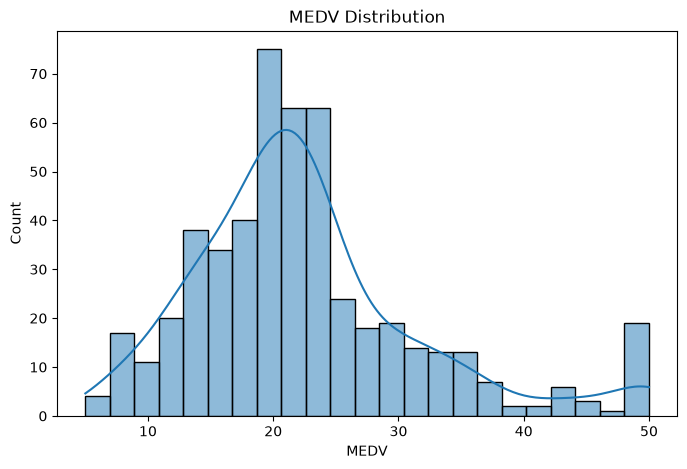

In [2]:
print("MEDV 평균:", df["medv"].mean())
print("MEDV 중앙값:", df["medv"].median())
print("MEDV 최소값:", df["medv"].min())
print("MEDV 최대값:", df["medv"].max())

plt.figure(figsize=(8, 5))
sns.histplot(df["medv"], kde=True)
plt.title("MEDV Distribution")
plt.xlabel("MEDV")
plt.ylabel("Count")
plt.show()


## 3. 문제 2 - RM(평균 방 개수)과 MEDV의 관계

평균 방 개수(`rm`)와 주택가격(`medv`)의 관계를 산점도로 확인합니다.

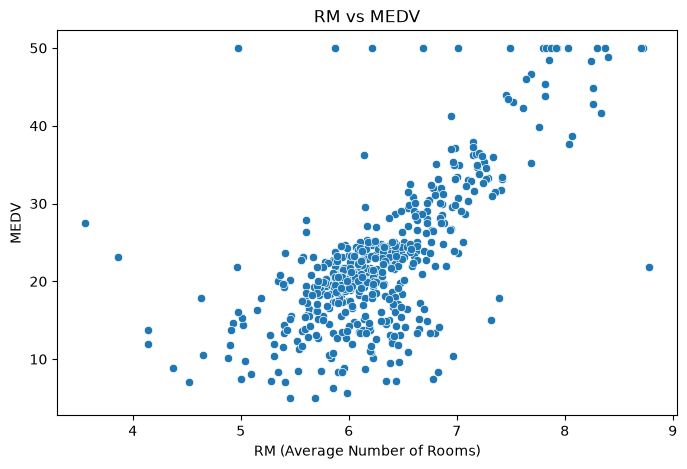

RM과 MEDV의 상관계수: 0.6953599470715395


In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="rm", y="medv")
plt.title("RM vs MEDV")
plt.xlabel("RM (Average Number of Rooms)")
plt.ylabel("MEDV")
plt.show()

print("RM과 MEDV의 상관계수:", df["rm"].corr(df["medv"]))


## 4. 문제 3 - LSTAT(저소득층 비율)과 MEDV의 관계

`lstat`과 `medv`의 관계를 확인합니다.

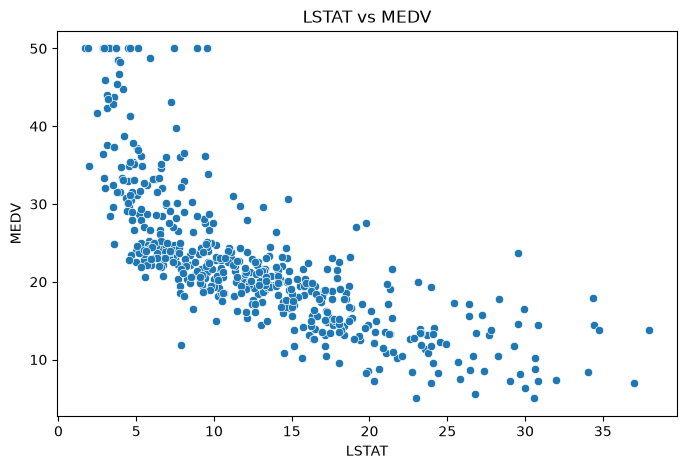

LSTAT과 MEDV의 상관계수: -0.7376627261740147


In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="lstat", y="medv")
plt.title("LSTAT vs MEDV")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.show()

print("LSTAT과 MEDV의 상관계수:", df["lstat"].corr(df["medv"]))


## 5. 문제 4 - CRIM(범죄율)과 MEDV의 관계

`crim`과 `medv`의 관계를 확인합니다.

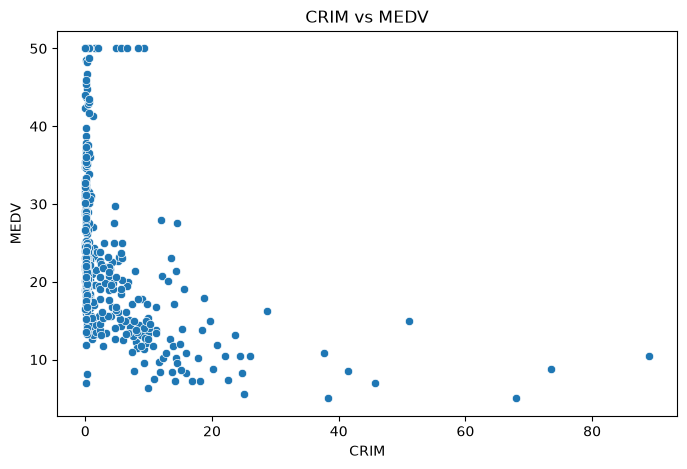

CRIM과 MEDV의 상관계수: -0.3883046085868113


In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="crim", y="medv")
plt.title("CRIM vs MEDV")
plt.xlabel("CRIM")
plt.ylabel("MEDV")
plt.show()

print("CRIM과 MEDV의 상관계수:", df["crim"].corr(df["medv"]))


## 6. 상관관계 확인

모델에 사용할 특성들과 목표변수 `medv` 사이의 Pearson 상관계수를 확인합니다.

In [6]:
# 행 번호 컬럼은 제외
feature_cols = [c for c in df.columns if c not in ["Unnamed: 0", "medv"]]

corr = df[feature_cols + ["medv"]].corr()

print(corr["medv"].sort_values(ascending=False))


medv       1.000000
rm         0.695360
zn         0.360445
black      0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


## 7. 상관관계 히트맵

변수들 사이의 상관관계를 색으로 표현합니다.

- +1에 가까움: 강한 양의 상관관계
- 0에 가까움: 선형 상관관계가 약함
- -1에 가까움: 강한 음의 상관관계


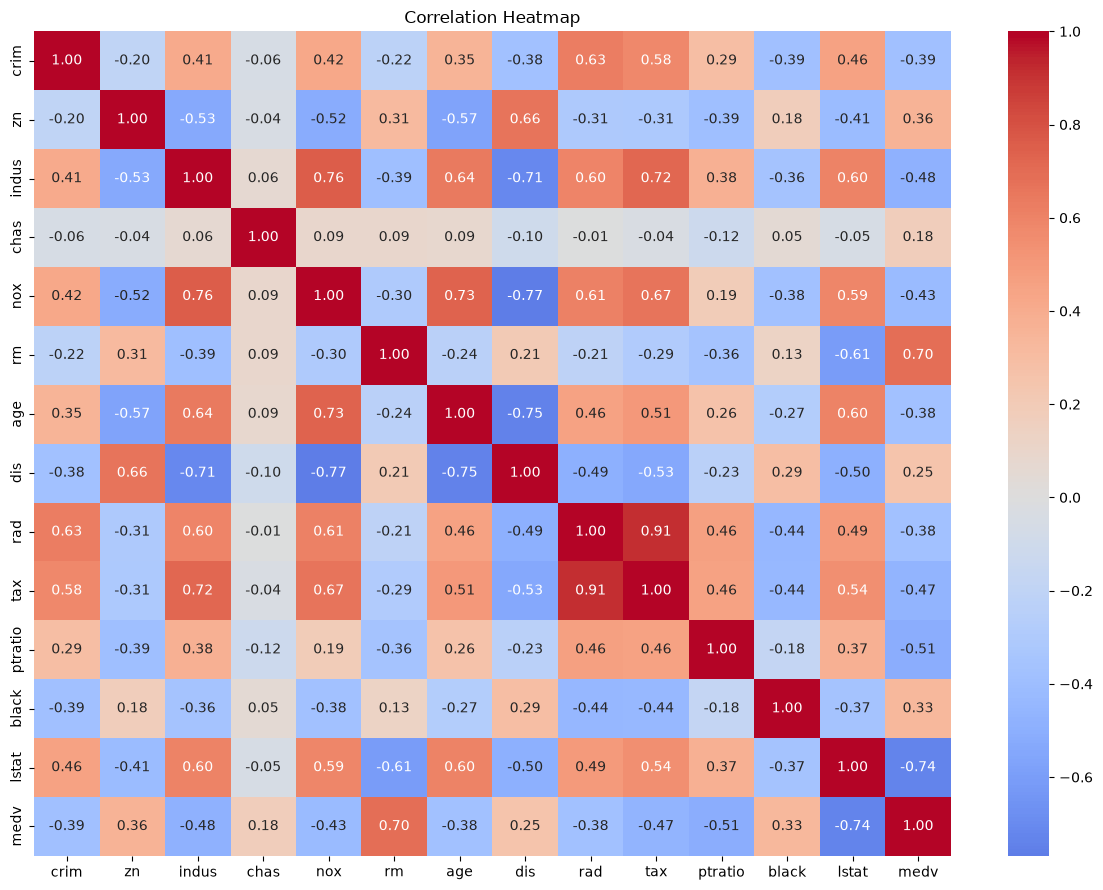

In [7]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 8. VIF 확인

VIF(Variance Inflation Factor)는 독립변수들 사이의 다중공선성을 확인하는 지표입니다.

일반적으로 VIF가 높을수록 해당 변수가 다른 독립변수들과 강하게 선형적으로 연관되어 있을 가능성이 있습니다.


In [9]:
X_vif = df[feature_cols].copy()

vif = pd.DataFrame()
vif["feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)
display(vif)


,feature,VIF
9,tax,9.008554
8,rad,7.484496
4,nox,4.393720
2,indus,3.991596
7,dis,3.955945
6,age,3.100826
12,lstat,2.941491
1,zn,2.298758
5,rm,1.933744
10,ptratio,1.799084


## 9. 정규화(Standardization)

선형회귀에 사용할 특성 데이터의 스케일을 맞추기 위해 `StandardScaler`를 사용합니다.

표준화 후 각 특성은 평균이 0, 표준편차가 1에 가까운 형태가 됩니다.

> 데이터 누수를 방지하기 위해 **Train 데이터에만 `fit`**하고, Test 데이터에는 `transform`만 적용합니다.


In [10]:
X = df[feature_cols]
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (404, 13)
X_test : (102, 13)
y_train: (404,)
y_test : (102,)


## 10. 선형회귀 모델 학습

특성 데이터(`crim` ~ `lstat`)를 이용하여 주택가격 중앙값 `medv`를 예측합니다.

In [11]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("절편:", model.intercept_)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

display(coef_df)


절편: 22.796534653465343


,feature,coefficient
5,rm,3.145240
8,rad,2.251407
11,black,1.129568
3,chas,0.718738
1,zn,0.696269
2,indus,0.278065
6,age,-0.176048
0,crim,-1.002135
9,tax,-1.767014
4,nox,-2.022319


## 11. 예측값 계산

In [12]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Train 예측값 일부:")
print(y_train_pred[:10])

print("\nTest 예측값 일부:")
print(y_test_pred[:10])


Train 예측값 일부:
[10.96952405 19.41196567 23.06419602 12.1470648  18.3738116  25.24677946
 20.77024774 23.90932632  7.81713319 19.60988098]

Test 예측값 일부:
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597]


## 12. 실제값과 예측값 Plot

Test 데이터의 실제 주택가격과 모델이 예측한 주택가격을 비교합니다.

점선에 가까울수록 예측값과 실제값이 비슷합니다.

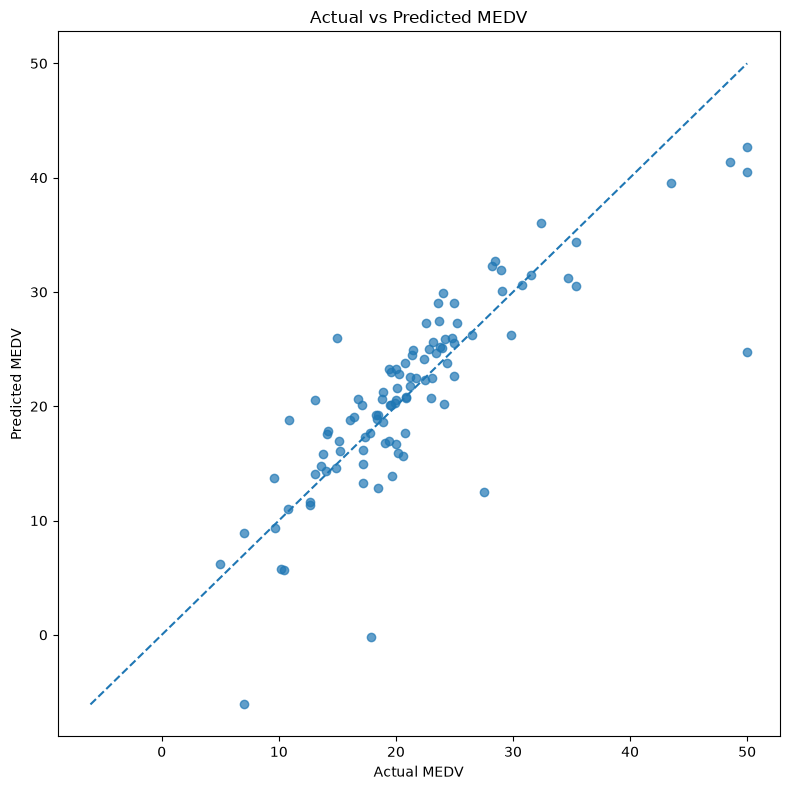

In [13]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_test_pred, alpha=0.7)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted MEDV")
plt.tight_layout()
plt.show()


## 13. Train / Test 결정계수($R^2$)

$R^2$는 모델이 목표변수의 변동을 얼마나 설명하는지를 나타내는 지표입니다.

- 1에 가까울수록 데이터에 잘 맞음
- 0이면 평균값을 사용하는 것과 비슷한 수준
- 음수가 될 수도 있음


In [14]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


Train R²: 0.7509
Test  R²: 0.6688


## 14. 결과 요약

- `RM`과 `MEDV`의 상관관계를 확인했습니다.
- `LSTAT`과 `MEDV`의 상관관계를 확인했습니다.
- `CRIM`과 `MEDV`의 상관관계를 확인했습니다.
- 전체 특성 간 상관관계를 히트맵으로 확인했습니다.
- VIF를 이용하여 다중공선성을 확인했습니다.
- `StandardScaler`로 특성 데이터를 표준화했습니다.
- Train/Test 데이터를 80:20으로 분할했습니다.
- 선형회귀를 이용하여 `MEDV`를 예측했습니다.
- 실제값과 예측값을 Plot으로 비교했습니다.
- Train과 Test의 $R^2$를 각각 계산했습니다.
